# Postituse tasemel mudelite võrdlus


In [33]:
%pip install scikit-learn
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import config
from openai import OpenAI
import seaborn as sns
import matplotlib.pyplot as plt



TARGET = "HubSpot"
LOW_PATH = "../data/cleaned_data/low_clean.json"
HIGH_PATH = "../data/cleaned_data/high_clean.json"

c:\Users\annmarle\Desktop\Redditi postituste automaatne klassifitseerimine erineva signaalitasemega keskkondades\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Meelestatus

## Andmete lugemine


In [2]:
low = pd.read_json(LOW_PATH)
high = pd.read_json(HIGH_PATH)

low["source_set"] = "low"
high["source_set"] = "high"

data = pd.concat([low, high], ignore_index=True)

# kasutame ainult postituse taset
data = data.dropna(subset=["clean_post_text"]).copy()
data["clean_post_text"] = data["clean_post_text"].astype(str).str.strip()
data = data[data["clean_post_text"] != ""].reset_index(drop=True)

print("Low posts:", len(low))
print("High posts:", len(high))
print("All usable posts:", len(data))


Low posts: 279
High posts: 987
All usable posts: 1266


In [3]:
data[["id", "subreddit_name", "source_set", "clean_post_text"]].head(5)

,id,subreddit_name,source_set,clean_post_text
0,1rt6kxz,marketing,low,How do you manage conference event ROI? Our co...
1,1r94q3j,marketing,low,Struggling with HubSpot mobile optimization on...
2,1r8b32m,marketing,low,"Marketing ,Sales alignment is killing me. Anyo..."
3,1quofd6,marketing,low,Hubspot vs. Meta Tracking Hello dear marketers...
4,1q7l645,marketing,low,HubSpot requirements everywhere in B2B - how d...


## Mudelid

In [4]:
print("Laen overall sentiment mudelit...")
tok_sent = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model_sent = AutoModelForSequenceClassification.from_pretrained(
    "cardiffnlp/twitter-roberta-base-sentiment-latest"
)

print("Laen topic sentiment mudelit...")
tok_topic = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-topic-sentiment-latest")
model_topic = AutoModelForSequenceClassification.from_pretrained(
    "cardiffnlp/twitter-roberta-base-topic-sentiment-latest"
)

labels_sent = ["negative", "neutral", "positive"]
labels_topic = ["strongly negative", "negative", "negative or neutral", "positive", "strongly positive"]

Laen overall sentiment mudelit...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 600.09it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Laen topic sentiment mudelit...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 815.08it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-topic-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Meelestatuse määramine

In [5]:
def predict_overall_sentiment(text: str):
    inputs = tok_sent(text, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model_sent(**inputs)
        probs = F.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    return {
        "overall_label": labels_sent[pred_idx],
        "overall_negative": float(probs[0]),
        "overall_neutral": float(probs[1]),
        "overall_positive": float(probs[2]),
    }


def predict_topic_sentiment(text: str, target: str):
    combined = f"{text} </s> {target}"
    inputs = tok_topic(combined, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model_topic(**inputs)
        probs = F.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    return {
        "topic_label": labels_topic[pred_idx],
        "topic_strongly_negative": float(probs[0]),
        "topic_negative": float(probs[1]),
        "topic_negative_or_neutral": float(probs[2]),
        "topic_positive": float(probs[3]),
        "topic_strongly_positive": float(probs[4]),
    }

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [14]:
def llm_sentiment(text: str, target: str):

    prompt = f'''
    You are a sentiment analysis expert evaluating Reddit posts about specific companies.

    Target company: {target}
    Post: {text}

    Classify the sentiment of the post specifically toward {target}.
    If the post does not mention or relate to {target}, return "neutral" with low confidence.

    Return only this JSON without any additional text.
    {{
        "sentiment": "positive" | "negative" | "neutral",
        "confidence": 0.0,
        "reasoning": "one sentence explanation"
    }}
    '''
    try: 
        response = client.responses.create(
            model="gpt-4.1-mini",
            input=prompt,
        )

        raw = response.output_text.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()

        analysis = json.loads(raw)
        return analysis
    
    except json.JSONDecodeError as e:
        print("JSON error on:" + response.output_text)
        return{
            "sentiment": "neutral",
            "confidence": 0.0,
            "reasoning": "ERROR: JSON error"
        }


In [21]:
rows = []

start_time = time.time()

for i, row in data.iterrows():
    text = row["clean_post_text"]

    overall_res = predict_overall_sentiment(text)
    topic_res = predict_topic_sentiment(text, TARGET)

    out = {
        "id": row.get("id"),
        "subreddit_name": row.get("subreddit_name"),
        "source_set": row.get("source_set"),
        "score": row.get("score"),
        "created_utc": row.get("created_utc"),
        "clean_post_text": text,
        **overall_res,
        **topic_res,
    }

    try:
        llm_res = llm_sentiment(text, TARGET)

        out.update({
            "llm_sentiment": llm_res.get("sentiment", "neutral"),
            "llm_confidence": llm_res.get("confidence", 0.0),
            "llm_reasoning": llm_res.get("reasoning", "")
        })

    except Exception as e:
        out.update({
            "llm_sentiment": "neutral",
            "llm_confidence": 0.0,
            "llm_reasoning": f"ERROR: {e}"
        })

    rows.append(out)

    if (i + 1) % 50 == 0 or (i + 1) == len(data):
        print(i+1)



results = pd.DataFrame(rows)

seconds = time.time() - start_time
print(f"Aega läks: {seconds:.2f} s")

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1266
Aega läks: 3013.79 s


In [54]:
import os
os.makedirs("../data/results", exist_ok=True)
results.to_json("../data/results/post_level_results.json", orient="records", indent=2, force_ascii=False)
results.to_csv("../data/results/post_level_results.csv",index=False,encoding="utf-8")

# Tulemuste võrdlus

In [6]:
results = pd.read_csv("../data/results/post_level_results.csv")
results.rename(columns={"llm_sentiment": "llm_label"}, inplace=True)
results.columns

Index(['id', 'subreddit_name', 'source_set', 'score', 'created_utc',
       'clean_post_text', 'overall_label', 'overall_negative',
       'overall_neutral', 'overall_positive', 'topic_label',
       'topic_strongly_negative', 'topic_negative',
       'topic_negative_or_neutral', 'topic_positive',
       'topic_strongly_positive', 'llm_label', 'llm_confidence',
       'llm_reasoning'],
      dtype='str')

In [7]:
results[["id", "subreddit_name", "source_set", "clean_post_text","overall_label", "topic_label", "llm_label"]].head()

,id,subreddit_name,source_set,clean_post_text,overall_label,topic_label,llm_label
0,1rt6kxz,marketing,low,How do you manage conference event ROI? Our co...,neutral,negative or neutral,neutral
1,1r94q3j,marketing,low,Struggling with HubSpot mobile optimization on...,negative,negative or neutral,negative
2,1r8b32m,marketing,low,"Marketing ,Sales alignment is killing me. Anyo...",negative,negative,neutral
3,1quofd6,marketing,low,Hubspot vs. Meta Tracking Hello dear marketers...,neutral,negative or neutral,negative
4,1q7l645,marketing,low,HubSpot requirements everywhere in B2B - how d...,neutral,negative or neutral,neutral


### Mudelite meelestatuse jaotuste võrdlustabelid

In [8]:
# Teeme topic based meelestatuse viis klassi kolmeks klassiks

# Võtame "strongly negative" ja "negative" kokku -> "negative"
# Muudame "negative or neutral" -> "neutral"
# Võtame "strongly positive" ja "positive" kokku -> "positive"
def topic_to_3(label):
    if label in ["strongly negative", "negative"]:
        return "negative"
    if label == "negative or neutral":
        return "neutral"
    if label in ["positive", "strongly positive"]:
        return "positive"
    return label

results["topic_label_3class"] = results["topic_label"].apply(topic_to_3)

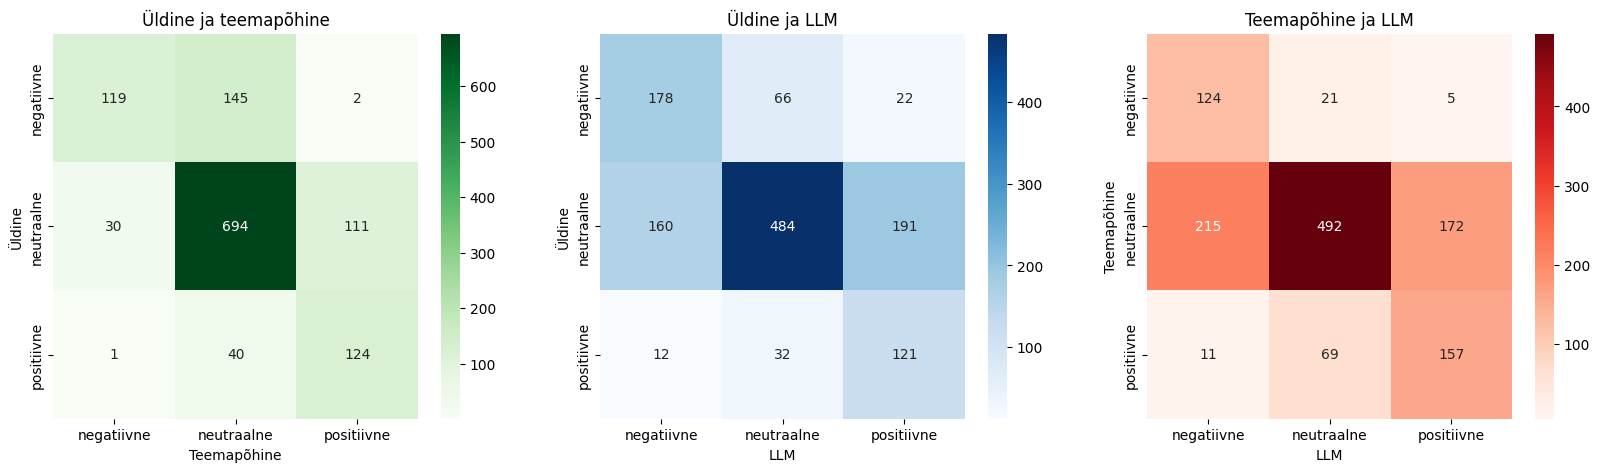

In [9]:
overall_vs_topic = pd.crosstab(results["overall_label"], results["topic_label_3class"])
overall_vs_llm = pd.crosstab(results["overall_label"], results["llm_label"])
topic_vs_llm = pd.crosstab(results["topic_label_3class"], results["llm_label"])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = ["negatiivne", "neutraalne", "positiivne"]

# Üldine ja teemapõhine
sns.heatmap(overall_vs_topic, annot=True, fmt="d",
    cmap="Greens", xticklabels=labels, yticklabels=labels, ax=axes[0])

axes[0].set_title("Üldine ja teemapõhine")
axes[0].set_xlabel("Teemapõhine")
axes[0].set_ylabel("Üldine")


# Üldine ja LLM
sns.heatmap(overall_vs_llm, annot=True, fmt="d",
    cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[1])

axes[1].set_title("Üldine ja LLM")
axes[1].set_xlabel("LLM")
axes[1].set_ylabel("Üldine")

# Teemapõhine ja LLM
sns.heatmap(topic_vs_llm, annot=True, fmt="d",
    cmap="Reds", xticklabels=labels, yticklabels=labels, ax=axes[2])

axes[2].set_title("Teemapõhine ja LLM")
axes[2].set_xlabel("LLM")
axes[2].set_ylabel("Teemapõhine")

plt.show();


### Võtame keskmise mudeli meelestatuse postituste pealt

In [10]:
posts_summary_data = pd.DataFrame({
    "overall": [
        (results["overall_label"] == "negative").mean(),
        (results["overall_label"] == "neutral").mean(),
        (results["overall_label"] == "positive").mean(),
    ],
    "topic": [
        (results["topic_label_3class"] == "negative").mean(),
        (results["topic_label_3class"] == "neutral").mean(),
        (results["topic_label_3class"] == "positive").mean(),
    ],
    "llm": [
        (results["llm_label"] == "negative").mean(),
        (results["llm_label"] == "neutral").mean(),
        (results["llm_label"] == "positive").mean(),
    ]
}, index=["negative", "neutral", "positive"])

posts_summary_data


,overall,topic,llm
negative,0.210111,0.118483,0.276461
neutral,0.659558,0.694313,0.459716
positive,0.130332,0.187204,0.263823


In [11]:
table = posts_summary_data.copy()
table.columns = ["Üldine mudel", "Teemapõhine mudel", "LLM (GPT-4.1-mini)"]
table.index = ["Negatiivne", "Neutraalne", "Positiivne"]
table = (table * 100).round(1)
table_display = table.astype(str) + "%"
table_display


,Üldine mudel,Teemapõhine mudel,LLM (GPT-4.1-mini)
Negatiivne,21.0%,11.8%,27.6%
Neutraalne,66.0%,69.4%,46.0%
Positiivne,13.0%,18.7%,26.4%


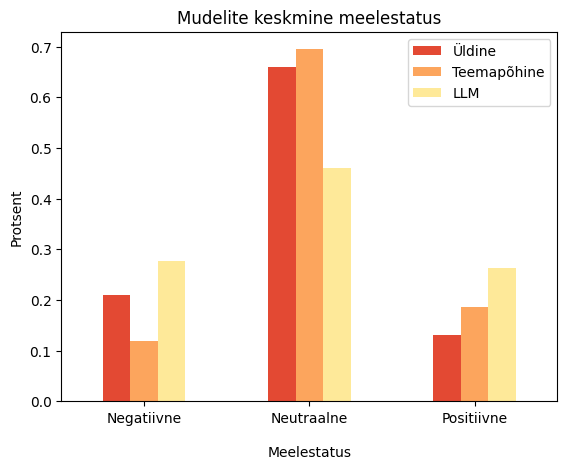

In [12]:

colors = sns.color_palette("RdYlGn", 6) 
posts_summary_data.plot(kind="bar", color=colors, )
plt.xticks(ticks=[0,1,2], labels=["Negatiivne", "Neutraalne", "Positiivne"],rotation=0)
plt.legend(["Üldine", "Teemapõhine", "LLM"])

plt.title("Mudelite keskmine meelestatus")
plt.xlabel("Meelestatus", labelpad=15)
plt.ylabel("Protsent")

plt.show()

Overall ja topic sildistavad neutraalseks võrreldes LLM-iga palju rohkem. 

## Erinevuste näited

In [13]:
pd.set_option('display.max_colwidth', None)

### overall ja topic

In [14]:
overall_topic_differneces = results[results["overall_label"] != results["topic_label_3class"]].copy()
print("Erinevusi kokku:", overall_topic_differneces.shape[0])

label_order = ["negative", "neutral", "positive"]

pairs = []
samples = []

for overall in label_order:
    for topic in label_order:
        # skip kui sama label (ei ole "difference")
        if overall == topic:
            continue
        
        subset = results[
            (results["overall_label"] == overall) &
            (results["topic_label_3class"] == topic)
        ]
        
        if len(subset) > 0:
            sample = subset.sample(1, random_state=42)
            samples.append(sample)

# liidame kõik kokku
pair_samples_1 = pd.concat(samples)

display(pair_samples_1[[
    "clean_post_text",
    "overall_label",
    "topic_label_3class"
]])

Erinevusi kokku: 329


,clean_post_text,overall_label,topic_label_3class
484,"whats hubspot bad at Hi, thinking about using hubspot, is there anything its not great at? Can automate some things outside of hubspot if its weak in some areas. Thanks!",negative,neutral
1117,"It’s time to actually use HubSpot’s lead capture tools I can’t tell you how many HubSpot portals I’ve opened where the lead capture tools are just sitting there. Forms not connected. Pop-ups disabled. Tracking code missing. And then people wonder why nothing new is coming into their CRM. I mean, you don’t need a huge strategy to start generating leads, you just need to use the basics that are already built in. Here’s where I’d start: * Install the tracking code on every page! * Add a simple form to your highest-traffic page (even a “Request pricing” or “Contact us” form) * Test out the meeting widget * Try one pop-up or slide-in with a clear helpful offer * Track what’s actually converting, not just what’s getting clicks. These are very easy tools to set up and use but they can make a huge difference. You’d be surprised how much growth comes from simply turning on what you already have. As someone who used to work at HubSpot and now helps clients set up and optimise their portals at [Baskey Digital]( I still find that the simplest setups often perform best. Any other HubSpot features you’ve seen make the biggest impact when a team finally started using it?",negative,positive
1106,"HubSpot API 404 on new Bach List Membership endpoint Hi all, Recently HubSpot announced a new batch endpoint for checking association list memberships by POST'ing to /crm/v3/lists/records/memberships/batch/read However, for some reason, I keep 404'ing to that endpoint. Does anyone else have this issue? Did anyone find a fix? Find the announcement [here]( 3rd heading. Find the API docs relevant to the new batch endpoint [here]( I'm experienced in building API-heavy workflows, and I am very confident my setup is correct. See attached screenshots for reference. I contacted Support, they replied quickly and said: ""Based on the error details, in fact it just looks like the endpoint is not available yet in your workspace. This usually happens when the endpoint is newly released but not fully rolled out to all portals."" In my experience, if they do a staged rollout they'd mention it clearly in communications and the error would not be a 404 but a 401 or 403. To me it seems like this endpoint should be available. Anyone experiencing a similar issue?",neutral,negative
891,Upgraded to Enterprise (Marketing and Content Hub) - what should be my first move? Upgraded from Pro to Enterprise (or whatever the level below enterprise is called). What are the obvious things I now have access to that I should take advantage of?,neutral,positive
975,"Database Damage on a Regular Basis I love AI, it's a tool that has improved my life in many ways when it comes to efficiency and workflow. I have never had so many disappointments though since I started with HubSpot around July or August. I am so tired of the unacceptable untrained AI changing phone numbers and deleting contacts that I actually work with. Rant over. I'm ready to ditch it.",positive,negative
659,"A question about HubSpot campaigns and UTM tracking Hi everyone, I hope you're having wonderful weeks. We're just starting to use campaigns in our HubSpot and I had a question. Say we have a campaign called ""ntc"" and I set the utm\_campaign parameter in the campaign manager to ""ntc"", do I then need to create the URLs inside the campaign manager, or can I carry on using a UTM spreadsheet, so long as I include the utm\_campaign as ""ntc"". Ideally, we'd like all of our PPC, email and outreach to have this UTM in for tracking.",positive,neutral


### overall ja llm

In [15]:
overall_llm_differences = results[results["overall_label"] != results["llm_label"]].copy()
print("Erinevusi kokku:", overall_llm_differences.shape[0])


samples = []

for overall in label_order:
    for llm in label_order:
        if overall == llm:
            continue
        
        subset = results[
            (results["overall_label"] == overall) &
            (results["llm_label"] == llm)
        ]
        
        if len(subset) > 0:
            samples.append(subset.sample(1, random_state=42))

pair_samples_2 = pd.concat(samples)

display(pair_samples_2[[
    "clean_post_text",
    "overall_label",
    "llm_label"
]])

Erinevusi kokku: 483


clean_post_text  \
831                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

### topic ja llm

In [16]:
topic_llm_differences = results[results["topic_label_3class"] != results["llm_label"]].copy()
print("Erinevusi kokku:", topic_llm_differences.shape[0])

samples = []

for topic in label_order:
    for llm in label_order:
        if topic == llm:
            continue
        
        subset = results[
            (results["topic_label_3class"] == topic) &
            (results["llm_label"] == llm)
        ]
        
        if len(subset) > 0:
            samples.append(subset.sample(1, random_state=42))

pair_samples_3 = pd.concat(samples)

display(pair_samples_3[[
    "clean_post_text",
    "topic_label_3class",
    "llm_label"
]])

Erinevusi kokku: 493


,clean_post_text,topic_label_3class,llm_label
2,"Marketing ,Sales alignment is killing me. Anyone actually solved this? Every quarter it's the same fight. Marketing says we delivered X leads. Sales says leads are garbage. We're using HubSpot for marketing automation and Salesforce for CRM but there's this black hole between 'MQL' and 'closed won' where nobody knows what happened. Attribution is a mess. Sales blames marketing, marketing blames sales. How have you actually solved this beyond just 'communicate better'?",negative,neutral
177,"ActiveCampaigns Deliverability Issue Hello, we recently switched from Hubspot to Active Campaigns for our newsletter/subreddit. We spam test with Glock Apps and the spam rate is way up from when we were on Hubspot. Lots of issues are outlined, none are content. URI tracking, which we tested turned off no improvement. Maybe a DMARC issue? It is a green check on the report. It is the same alias from Hubspot so should be warmed, we are also sending in batches of 100. Email hit worst is Gmail. I heard ActiveCampaigns deliverability was the best so I am confused why it dropped almost 50% any hel is appreciated.",negative,positive
1192,"Folders for Marketing Email Templates Anyone else use saved marketing email templates in HubSpot and struggle with organizing them? My company uses the Brands add-on and are the parent company to several small brands. We create corporate-approved content for our brands to use and distribute it through saved marketing email templates. The reason we distribute it this way instead of drafting marketing emails for the brands to clone is because we've had a number of brands unintentionally edit the original marketing email with their branding and send it out. However, we're generating a ton of templates between both of our HubSpot accounts in just the last couple of months and the template organization is driving me nuts. I've posted to the product team's community page but was hoping that someone on here might have a solution or workaround for this kind of issue. If you have a second and agree that this would be helpful, I'd appreciate an upvote on the community post! [",neutral,negative
449,"Custom integration work | HubSpot Partners Hey everyone, wanted to introduce myself and see if there's a fit here. **Background:** I come from sales/BD, and I'm now working with HubSpot agencies to handle their custom integration work, things like API builds, data migrations, custom workflows, and syncing external systems with HubSpot. **What I've been thinking about:** Most agencies I've talked to hit this ceiling where: * A client wants something custom but it's not standard HubSpot * Their team is already stretched thin on core implementation * They either have to say ""no"" to the project (lose revenue) or pull developers off other work (everything slows down) **That's where I come in.** I handle the technical heavy lifting so they can focus on strategy and keep their clients happy. I have worked with 10+ clients based out of UK and California I have a technical team with serious HubSpot expertise, for complex challenges. So I bring execution speed + access to deep platform knowledge. **What I'm looking for:** * Conversations with agencies (or anyone working with them) about their process * Understanding what's actually painful about custom development in the HubSpot space * Building genuine relationships, not transactional stuff **Questions I have for this community:** 1. For agencies reading this, when you run into custom integration work, what do you usually do? 2. Have you ever turned down a project because it required custom development you didn't have capacity for? 3. What would make it easier for you to take on more complex projects? I'm curious how this works from your perspective. Also happy to help if anyone here needs integration work done or wants to brainstorm solutions. Thanks for reading, and thanks in advance for any insight.",neutral,positive
142,"(Most Afforda

Overall ja topic on üksteisele kõige sarnasemad. LLM erineb mõlemas rohkem. 

In [17]:
overall_topic_differneces.shape[0]

329

In [18]:
total = results.shape[0]

comparison_table = pd.DataFrame({
    "Mudelid": [
        "Üldine vs teemapõhine",
        "Üldine vs LLM",
        "Teemapõhine vs LLM"
    ],
    "Erinevuste arv": [
        overall_topic_differneces.shape[0],
        overall_llm_differences.shape[0],
        topic_llm_differences.shape[0]
    ],
    "Erinevuste osakaal (%)": [
        overall_topic_differneces.shape[0] / total * 100,
        overall_llm_differences.shape[0] / total * 100,
        topic_llm_differences.shape[0] / total * 100
    ]
})

In [19]:
comparison_table["Erinevuste osakaal (%)"] = comparison_table["Erinevuste osakaal (%)"].round(1).astype(str) + "%"
comparison_table

,Mudelid,Erinevuste arv,Erinevuste osakaal (%)
0,Üldine vs teemapõhine,329,26.0%
1,Üldine vs LLM,483,38.2%
2,Teemapõhine vs LLM,493,38.9%


In [20]:
comparison_table.to_html(index=False)

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Mudelid</th>\n      <th>Erinevuste arv</th>\n      <th>Erinevuste osakaal (%)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Üldine vs teemapõhine</td>\n      <td>329</td>\n      <td>26.0%</td>\n    </tr>\n    <tr>\n      <td>Üldine vs LLM</td>\n      <td>483</td>\n      <td>38.2%</td>\n    </tr>\n    <tr>\n      <td>Teemapõhine vs LLM</td>\n      <td>493</td>\n      <td>38.9%</td>\n    </tr>\n  </tbody>\n</table>'

## Kuldstandardi loomise jaoks

In [18]:
pair_samples = pd.concat([pair_samples_1, pair_samples_2, pair_samples_3])

In [19]:
pair_samples.groupby("subreddit_name").size()

subreddit_name
CRM                  1
DigitalMarketing     1
hubspot             14
marketing            1
sales                1
dtype: int64

#### Valemid
olemas juba
* 14 - Kõrge
* 4 - Madal

Sample size valemi järgi vaja kokku 295 postitust. 
* Kõrge: 987 postitust: 987/1266 = 77.9% siit 295 * 0.779 = 230 .... 230 - 14 = 216
* Madal: 279 postitust: 279/1266 = 22.1% siit 295 * 0.221 = 65 ... 65 - 4 = 61



In [20]:
high = results[results["subreddit_name"] == "hubspot"]
low = results[results["subreddit_name"] != "hubspot"]

high = high.drop(pair_samples.index, errors="ignore")
low = low.drop(pair_samples.index, errors="ignore")

high_samples = high.sample(216, random_state=42)
low_samples = low.sample(61, random_state=42)

gold_standard = pd.concat([pair_samples, high_samples, low_samples])
len(gold_standard)

295

In [22]:
gold_standard.groupby("subreddit_name").size()

subreddit_name
CRM                  26
DigitalMarketing     13
Entrepreneur          5
b2bmarketing          7
hubspot             230
marketing             3
sales                 6
startups              1
techsales             4
dtype: int64

In [23]:
gold_standard[["id", "clean_post_text"]].assign(gold_label="").to_excel("../data/gold_standard.xlsx", index=False)

#### Kuldstandardiga võrdlemine

In [30]:
gold = pd.read_excel("../data/gold_standard_filled.xlsx")
gold.head()

,id,clean_post_text,gold_label
0,1rja6b1,"whats hubspot bad at Hi, thinking about using hubspot, is there anything its not great at? Can automate some things outside of hubspot if its weak in some areas. Thanks!",neutral
1,1oqfyfy,"It’s time to actually use HubSpot’s lead capture tools I can’t tell you how many HubSpot portals I’ve opened where the lead capture tools are just sitting there. Forms not connected. Pop-ups disabled. Tracking code missing. And then people wonder why nothing new is coming into their CRM. I mean, you don’t need a huge strategy to start generating leads, you just need to use the basics that are already built in. Here’s where I’d start: * Install the tracking code on every page! * Add a simple form to your highest-traffic page (even a “Request pricing” or “Contact us” form) * Test out the meeting widget * Try one pop-up or slide-in with a clear helpful offer * Track what’s actually converting, not just what’s getting clicks. These are very easy tools to set up and use but they can make a huge difference. You’d be surprised how much growth comes from simply turning on what you already have. As someone who used to work at HubSpot and now helps clients set up and optimise their portals at [Baskey Digital]( I still find that the simplest setups often perform best. Any other HubSpot features you’ve seen make the biggest impact when a team finally started using it?",positive
2,1ou6f0j,"HubSpot API 404 on new Bach List Membership endpoint Hi all, Recently HubSpot announced a new batch endpoint for checking association list memberships by POST'ing to /crm/v3/lists/records/memberships/batch/read However, for some reason, I keep 404'ing to that endpoint. Does anyone else have this issue? Did anyone find a fix? Find the announcement [here]( 3rd heading. Find the API docs relevant to the new batch endpoint [here]( I'm experienced in building API-heavy workflows, and I am very confident my setup is correct. See attached screenshots for reference. I contacted Support, they replied quickly and said: ""Based on the error details, in fact it just looks like the endpoint is not available yet in your workspace. This usually happens when the endpoint is newly released but not fully rolled out to all portals."" In my experience, if they do a staged rollout they'd mention it clearly in communications and the error would not be a 404 but a 401 or 403. To me it seems like this endpoint should be available. Anyone experiencing a similar issue?",negative
3,1prn89r,Upgraded to Enterprise (Marketing and Content Hub) - what should be my first move? Upgraded from Pro to Enterprise (or whatever the level below enterprise is called). What are the obvious things I now have access to that I should take advantage of?,neutral
4,1pfhtr2,"Database Damage on a Regular Basis I love AI, it's a tool that has improved my life in many ways when it comes to efficiency and workflow. I have never had so many disappointments though since I started with HubSpot around July or August. I am so tired of the unacceptable untrained AI changing phone numbers and deleting contacts that I actually work with. Rant over. I'm ready to ditch it.",negative


In [31]:
gold["gold_label"].unique()


<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

In [32]:
gold = gold.merge(results[["id", "source_set", "overall_label", "topic_label_3class", "llm_label"]], on="id")
gold

,id,clean_post_text,gold_label,source_set,overall_label,topic_label_3class,llm_label
0,1rja6b1,"whats hubspot bad at Hi, thinking about using hubspot, is there anything its not great at? Can automate some things outside of hubspot if its weak in some areas. Thanks!",neutral,high,negative,neutral,neutral
1,1oqfyfy,"It’s time to actually use HubSpot’s lead capture tools I can’t tell you how many HubSpot portals I’ve opened where the lead capture tools are just sitting there. Forms not connected. Pop-ups disabled. Tracking code missing. And then people wonder why nothing new is coming into their CRM. I mean, you don’t need a huge strategy to start generating leads, you just need to use the basics that are already built in. Here’s where I’d start: * Install the tracking code on every page! * Add a simple form to your highest-traffic page (even a “Request pricing” or “Contact us” form) * Test out the meeting widget * Try one pop-up or slide-in with a clear helpful offer * Track what’s actually converting, not just what’s getting clicks. These are very easy tools to set up and use but they can make a huge difference. You’d be surprised how much growth comes from simply turning on what you already have. As someone who used to work at HubSpot and now helps clients set up and optimise their portals at [Baskey Digital]( I still find that the simplest setups often perform best. Any other HubSpot features you’ve seen make the biggest impact when a team finally started using it?",positive,high,negative,positive,positive
2,1ou6f0j,"HubSpot API 404 on new Bach List Membership endpoint Hi all, Recently HubSpot announced a new batch endpoint for checking association list memberships by POST'ing to /crm/v3/lists/records/memberships/batch/read However, for some reason, I keep 404'ing to that endpoint. Does anyone else have this issue? Did anyone find a fix? Find the announcement [here]( 3rd heading. Find the API docs relevant to the new batch endpoint [here]( I'm experienced in building API-heavy workflows, and I am very confident my setup is correct. See attached screenshots for reference. I contacted Support, they replied quickly and said: ""Based on the error details, in fact it just looks like the endpoint is not available yet in your workspace. This usually happens when the endpoint is newly released but not fully rolled out to all portals."" In my experience, if they do a staged rollout they'd mention it clearly in communications and the error would not be a 404 but a 401 or 403. To me it seems like this endpoint should be available. Anyone experiencing a similar issue?",negative,high,neutral,negative,negative
3,1prn89r,Upgraded to Enterprise (Marketing and Content Hub) - what should be my first move? Upgraded from Pro to Enterprise (or whatever the level below enterprise is called). What are the obvious things I now have access to that I should take advantage of?,neutral,high,neutral,positive,positive
4,1pfhtr2,"Database Damage on a Regular Basis I love AI, it's a tool that has improved my life in many ways when it comes to efficiency and workflow. I have never had so many disappointments though since I started with HubSpot around July or August. I am so tired of the unacceptable untrained AI changing phone numbers and deleting contacts that I actually work with. Rant over. I'm ready to ditch it.",negative,high,positive,negative,negative
...,...,...,...,...,...,...,...
290,1qurx90,"Hubspot Lead Management Best Practices? Hi there, we set up our Hubspot account few months back and im kinda confused by the decisions made for how we gonna use it. Especially the Lead section. My feedback on this has been overlooked since it a fresh set up and the person responsible for this says its all good. Basically we create a lead record every-time a set action is made -> content download, webinar registration, book a demo or sales rep own need. While we have dedicated stage for all these leads, they just pile up there and stay there -> nobody has time t

In [38]:
from sklearn.metrics import accuracy_score

overall_accuracy = accuracy_score(gold["gold_label"], gold["overall_label"])
topic_accuracy = accuracy_score(gold["gold_label"], gold["topic_label_3class"])
llm_accuracy = accuracy_score(gold["gold_label"], gold["llm_label"])
print("Üldine mudel:", overall_accuracy)
print("Teemapõhine mudel:", topic_accuracy)
print("LLM:", llm_accuracy)


Üldine mudel: 0.5966101694915255
Teemapõhine mudel: 0.5796610169491525
LLM: 0.6847457627118644


In [41]:
high = gold[gold["source_set"] == "high"]
low = gold[gold["source_set"] == "low"]


overall_high = accuracy_score(high["gold_label"], high["overall_label"])
topic_high = accuracy_score(high["gold_label"], high["topic_label_3class"])
llm_high = accuracy_score(high["gold_label"], high["llm_label"])

overall_low = accuracy_score(low["gold_label"], low["overall_label"])
topic_low = accuracy_score(low["gold_label"], low["topic_label_3class"])
llm_low = accuracy_score(low["gold_label"], low["llm_label"])

table = pd.DataFrame({
    "Mudel": ["Üldine", "Teemapõhine", "LLM"],
    "Kokku": [ round(overall_accuracy * 100, 1), round(topic_accuracy * 100, 1), round(llm_accuracy * 100, 1)],
    "Kõrge": [round(overall_high * 100, 1),round(topic_high * 100, 1), round(llm_high * 100, 1)],
    "Madal": [round(overall_low * 100, 1), round(topic_low * 100, 1),round(llm_low * 100, 1)],
})

table["Kokku"] = table["Kokku"].astype(str) + "%"
table["Kõrge"] = table["Kõrge"].astype(str) + "%"
table["Madal"] = table["Madal"].astype(str) + "%"

table = table.set_index("Mudel")
table

,Kokku,Kõrge,Madal
Mudel,,,
Üldine,59.7%,60.4%,56.9%
Teemapõhine,58.0%,58.3%,56.9%
LLM,68.5%,69.6%,64.6%
